In [367]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import module.rb85_bloch as rb85_bloch

importlib.reload(rb85_bloch)

<module 'module.rb85_bloch' from '/Users/alban/Library/Mobile Documents/com~apple~CloudDocs/ENSCP/Stage Glasgow/sim_project/Rb85_bloch_sim/module/rb85_bloch.py'>

## Choisissons notre vecteur B

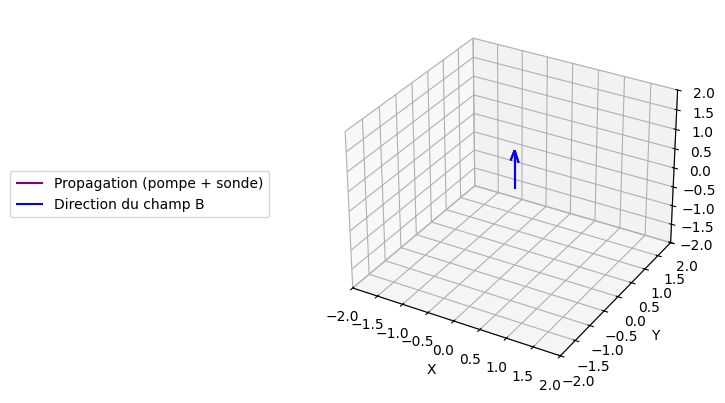

In [368]:
B_vec = [0, 0, 1]  
B_norm = 0.5  # G

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

K_vec = np.array([0, 0, 1])   # axe de propagation pompe+sonde = axe de quantification fixe du module

ax.quiver(0, 0, 0, K_vec[0], K_vec[1], K_vec[2], color="purple", label="Propagation (pompe + sonde)")
ax.quiver(0, 0, 0, B_vec[0], B_vec[1], B_vec[2], color="blue", label="Direction du champ B")

ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend(loc='center right', bbox_to_anchor=(-0.15, 0.5), borderaxespad=0.)

plt.title("")
plt.show()

# Contrairement a rb85_cell.py, ce module construit H directement dans le
# repere (e1, e2, k_hat) : il n'y a pas de rotation "B vers k_hat" a faire,
# B_vec EST deja exprime dans ce repere (voir zeeman_hamiltonian).
B = np.array(B_vec, dtype=float)
B = B_norm * B / np.linalg.norm(B)
B_T = B * 1e-4

## Paramètres du pompage et de la cellule, résolution de l'état stationnaire

In [369]:
pump_s = 0.6  #1.65 / 1.669        # I_pump / I_sat
pump_detuning = 0.0
gamma_t = 3.0e4              # relaxation par temps de transit, rad/s
n_rho = 5.383e13             # densite atomique, m^-3
L_cell = 75e-3               # longueur de propagation, m

rho_ss, L = rb85_bloch.steady_state_rho_closed(B_T, pump_s, pump_detuning, gamma_t)
diag = rb85_bloch.diagnostics(rho_ss, L, gamma_t)

print("=== Diagnostics de l'etat stationnaire ===")
for key, val in diag.items():
    print(f"{key:20s}: {val}")

=== Diagnostics de l'etat stationnaire ===
trace               : (0.9999999999999809+0j)
hermiticity_error   : 0.0
absolute_residual   : 1.6063078647905894e-09
relative_residual   : 4.602115298551373e-17
min_eigenvalue      : 0.0


## Répartition de population (état stationnaire)

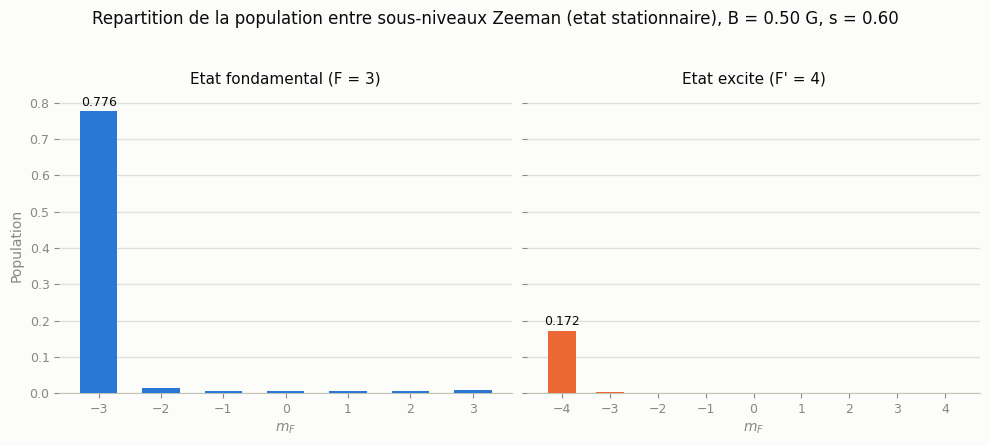

Population totale F=3   : 0.8238
Population totale F'=4  : 0.1762


In [370]:
COLOR_GROUND = "#2a78d6"
COLOR_EXCITED = "#eb6834"
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_MUTED = "#898781"
COLOR_INK = "#0b0b0b"
COLOR_SURFACE = "#fcfcfb"

ground_population = np.real(np.diag(rho_ss))[: rb85_bloch.N_G]
excited_population = np.real(np.diag(rho_ss))[rb85_bloch.N_G :]

fig, (ax_ground, ax_excited) = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
fig.patch.set_facecolor(COLOR_SURFACE)

for ax, m_values, populations, title, color in (
    (ax_ground, rb85_bloch.MF3, ground_population, "Etat fondamental (F = 3)", COLOR_GROUND),
    (ax_excited, rb85_bloch.MFP4, excited_population, "Etat excite (F' = 4)", COLOR_EXCITED),
):
    ax.set_facecolor(COLOR_SURFACE)
    ax.bar(m_values, populations, width=0.6, color=color, zorder=3)

    top_index = int(np.argmax(populations))
    ax.annotate(
        f"{populations[top_index]:.3f}",
        (m_values[top_index], populations[top_index]),
        textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9, color=COLOR_INK,
    )
    ax.set_title(title, fontsize=11, color=COLOR_INK, pad=10)
    ax.set_xlabel(r"$m_F$", fontsize=10, color=COLOR_MUTED)
    ax.set_xticks(m_values)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(COLOR_AXIS)
    ax.tick_params(colors=COLOR_MUTED, labelsize=9)

ax_ground.set_ylabel("Population", fontsize=10, color=COLOR_MUTED)
fig.suptitle(
    f"Repartition de la population entre sous-niveaux Zeeman (etat stationnaire), "
    f"B = {B_norm:.2f} G, s = {pump_s:.2f}",
    fontsize=12, color=COLOR_INK,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

print(f"Population totale F=3   : {ground_population.sum():.4f}")
print(f"Population totale F'=4  : {excited_population.sum():.4f}")

## Susceptibilité de la sonde

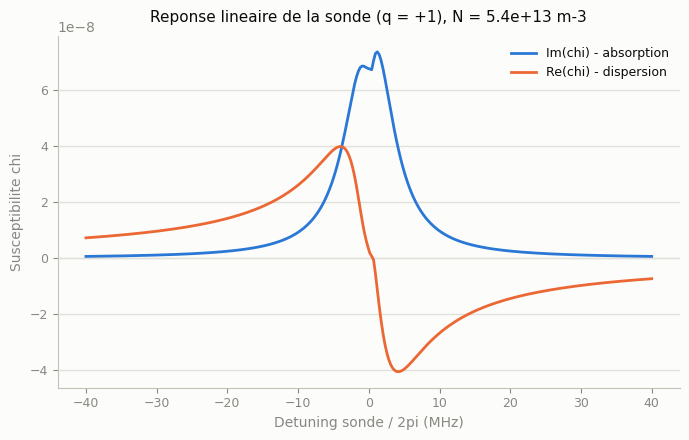

In [371]:
q_probe = 1  # polarisation de la sonde ; -1 = meme polarisation que la pompe
V_probe = rb85_bloch.dipole_coupling_operator(q_probe)

probe_detunings_MHz = np.linspace(-40, 40, 300)
probe_detunings_rad = 2 * np.pi * probe_detunings_MHz * 1e6

chi_probe = rb85_bloch.chi_tensor_from_rho(probe_detunings_rad, rho_ss, L, n_rho)
chi_qq = chi_probe[:, q_probe + 1, q_probe + 1]  # element diagonal correspondant a q_probe

fig2, ax_chi = plt.subplots(figsize=(7, 4.5))
fig2.patch.set_facecolor(COLOR_SURFACE)
ax_chi.set_facecolor(COLOR_SURFACE)

ax_chi.axhline(0, color=COLOR_GRID, linewidth=1, zorder=1)
ax_chi.plot(
    probe_detunings_MHz, chi_qq.imag,
    color=COLOR_GROUND, linewidth=2, label="Im(chi) - absorption", zorder=3,
)
ax_chi.plot(
    probe_detunings_MHz, chi_qq.real,
    color=COLOR_EXCITED, linewidth=2, label="Re(chi) - dispersion", zorder=3,
)

ax_chi.set_xlabel("Detuning sonde / 2pi (MHz)", fontsize=10, color=COLOR_MUTED)
ax_chi.set_ylabel("Susceptibilite chi", fontsize=10, color=COLOR_MUTED)
ax_chi.set_title(
    f"Reponse lineaire de la sonde (q = {q_probe:+d}), N = {n_rho:.1e} m-3",
    fontsize=11, color=COLOR_INK, pad=10,
)
ax_chi.grid(axis="y", color=COLOR_GRID, linewidth=1, zorder=0)
ax_chi.set_axisbelow(True)
for spine in ("top", "right"):
    ax_chi.spines[spine].set_visible(False)
ax_chi.spines["left"].set_color(COLOR_AXIS)
ax_chi.spines["bottom"].set_color(COLOR_AXIS)
ax_chi.tick_params(colors=COLOR_MUTED, labelsize=9)

legend = ax_chi.legend(frameon=False, fontsize=9, loc="best")
for text in legend.get_texts():
    text.set_color(COLOR_INK)

fig2.tight_layout()
plt.show()

## Maintenant définissons notre champ électrique en entrée

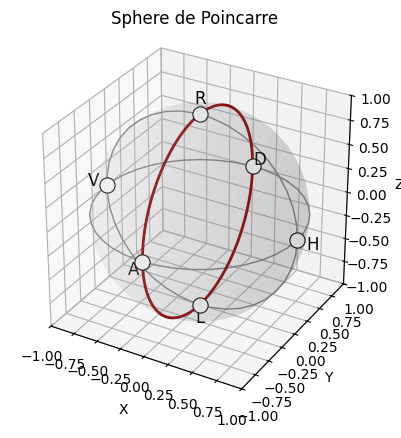

In [372]:
# Coupe centrale parametrable
# changez cut_theta et cut_phi pour choisir une nouvelle orientation de coupe
cut_theta = 0 * np.pi / 2  # angle azimutal dans le plan XY
cut_phi = 1 * np.pi / 2    # angle polaire depuis l'axe Z

fig = plt.figure()

ax = fig.add_subplot(111, projection="3d")

# Sphere de Poincarre
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 20)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(x, y, z, color='lightgray', alpha=0.12, linewidth=0)
ax.plot(np.cos(u), np.sin(u), np.zeros_like(u), color='gray', linewidth=1)
ax.plot(np.cos(u), np.zeros_like(u), np.sin(u), color='gray', linewidth=1)
ax.plot(np.zeros_like(u), np.cos(u), np.sin(u), color='gray', linewidth=1)

cut_normal = np.array([
    np.sin(cut_phi) * np.cos(cut_theta),
    np.sin(cut_phi) * np.sin(cut_theta),
    np.cos(cut_phi)
])
cut_normal = cut_normal / np.linalg.norm(cut_normal)
helper = np.array([1.0, 0.0, 0.0])
if abs(np.dot(helper, cut_normal)) > 0.9:
    helper = np.array([0.0, 1.0, 0.0])
e1 = np.cross(cut_normal, helper)
e1 = e1 / np.linalg.norm(e1)
e2 = np.cross(cut_normal, e1)
t = np.linspace(0, 2 * np.pi, 120)
cut_circle = np.outer(np.cos(t), e1) + np.outer(np.sin(t), e2)
ax.plot(cut_circle[:, 0], cut_circle[:, 1], cut_circle[:, 2], color='darkred', linewidth=2, label='Coupe centrale')

points = {
    'H': (1, 0, 0), 'V': (-1, 0, 0),
    'D': (0, 1, 0), 'A': (0, -1, 0),
    'R': (0, 0, 1), 'L': (0, 0, -1),
}
for label, (x0, y0, z0) in points.items():
    ax.scatter([x0], [y0], [z0], color='white', s=120, edgecolors='black', linewidths=0.8)
    ax.text(x0 * 1.15, y0 * 1.15, z0 * 1.15, label, color='black', fontsize=12, ha='center', va='center')

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_box_aspect([1, 1, 1])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title("Sphere de Poincarre")
plt.show()

# Conversion Poincarre -> Jones : (s1, s2, s3) -> [Ex, Ey] complexe
def E_in_on_cut(theta_along_cut):
    s1, s2, s3 = np.cos(2 * theta_along_cut) * e1 + np.sin(2 * theta_along_cut) * e2
    alpha = np.arccos(np.clip(s1, -1.0, 1.0)) / 2
    delta = np.arctan2(s3, s2)
    return np.array([np.cos(alpha), np.sin(alpha) * np.exp(1j * delta)])

theta_values = np.linspace(0, 2 * np.pi, 181)
E_in_list = np.array([E_in_on_cut(theta) for theta in theta_values])  # (181, 2) complexe

## Traçons E_out pour une série de détunings

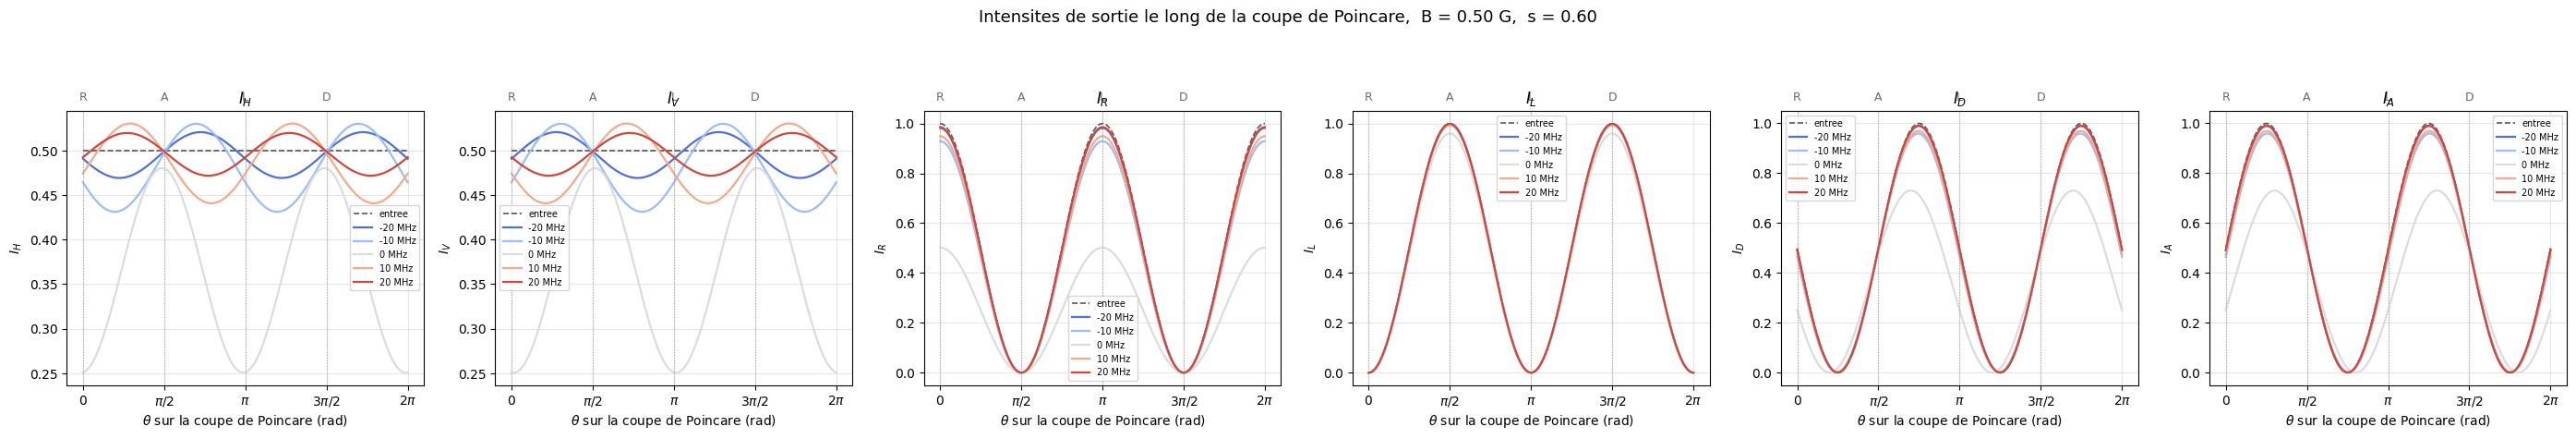

In [373]:
GAMMA = rb85_bloch.GAMMA

highlight_detunings_MHz = [-20, -10, 0, 10, 20]
detunings_rad = 2 * np.pi * np.array(highlight_detunings_MHz) * 1e6

# Une seule resolution de l'etat stationnaire pour ce B, reutilisee pour
# tous les detunings ET tous les E_in (contrairement a rb85_cell.propagate,
# ici chaque solve est un vrai calcul, pas une formule fermee -- appeler
# jones_matrix_closed 181 fois serait 181x plus lent pour rien).
J_highlight = rb85_bloch.jones_matrix_closed(
    detunings_rad, B_T, pump_s, L_cell, n_rho,
    pump_detuning=pump_detuning, gamma_t=gamma_t,
)
E_out_all = np.einsum('dij,tj->tdi', J_highlight, E_in_list)  # (theta, detuning, champ)

I_out_all = rb85_bloch.polarization_intensities(E_out_all)
I_in      = rb85_bloch.polarization_intensities(E_in_list)

output_intensities = {
    det_MHz: {k: v[:, j] for k, v in I_out_all.items()}
    for j, det_MHz in enumerate(highlight_detunings_MHz)
}

canon_x     = [0, np.pi / 2, np.pi, 3 * np.pi / 2]
canon_names = ["R", "A", "L", "D"]
highlight_colors = plt.cm.coolwarm(np.linspace(0.08, 0.92, len(highlight_detunings_MHz)))

fig, axs = plt.subplots(1, 6, figsize=(28, 4.8), sharex=True)
fig.suptitle(
    f"Intensites de sortie le long de la coupe de Poincare,  B = {B_norm:.2f} G,  s = {pump_s:.2f}",
    fontsize=13,
)

for ax, key, label in [
    (axs[0], 'H', '$I_H$'), (axs[1], 'V', '$I_V$'),
    (axs[2], 'R', '$I_R$'), (axs[3], 'L', '$I_L$'),
    (axs[4], 'D', '$I_D$'), (axs[5], 'A', '$I_A$'),
]:
    ax.plot(theta_values, I_in[key], linestyle="--", color="black", linewidth=1.2, alpha=0.65, label="entree")
    for det_MHz, color in zip(highlight_detunings_MHz, highlight_colors):
        ax.plot(theta_values, output_intensities[det_MHz][key], color=color, linewidth=1.6, label=f"{det_MHz:g} MHz")
    for cx, cname in zip(canon_x, canon_names):
        ax.axvline(cx, color="gray", linewidth=0.8, linestyle=":", alpha=0.65)
        ax.text(cx, 1.03, cname, transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=9, color="dimgray")
    ax.set_title(label)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_xlabel(r"$\theta$ sur la coupe de Poincare (rad)")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

## Traçons E_out pour une série de valeurs de B

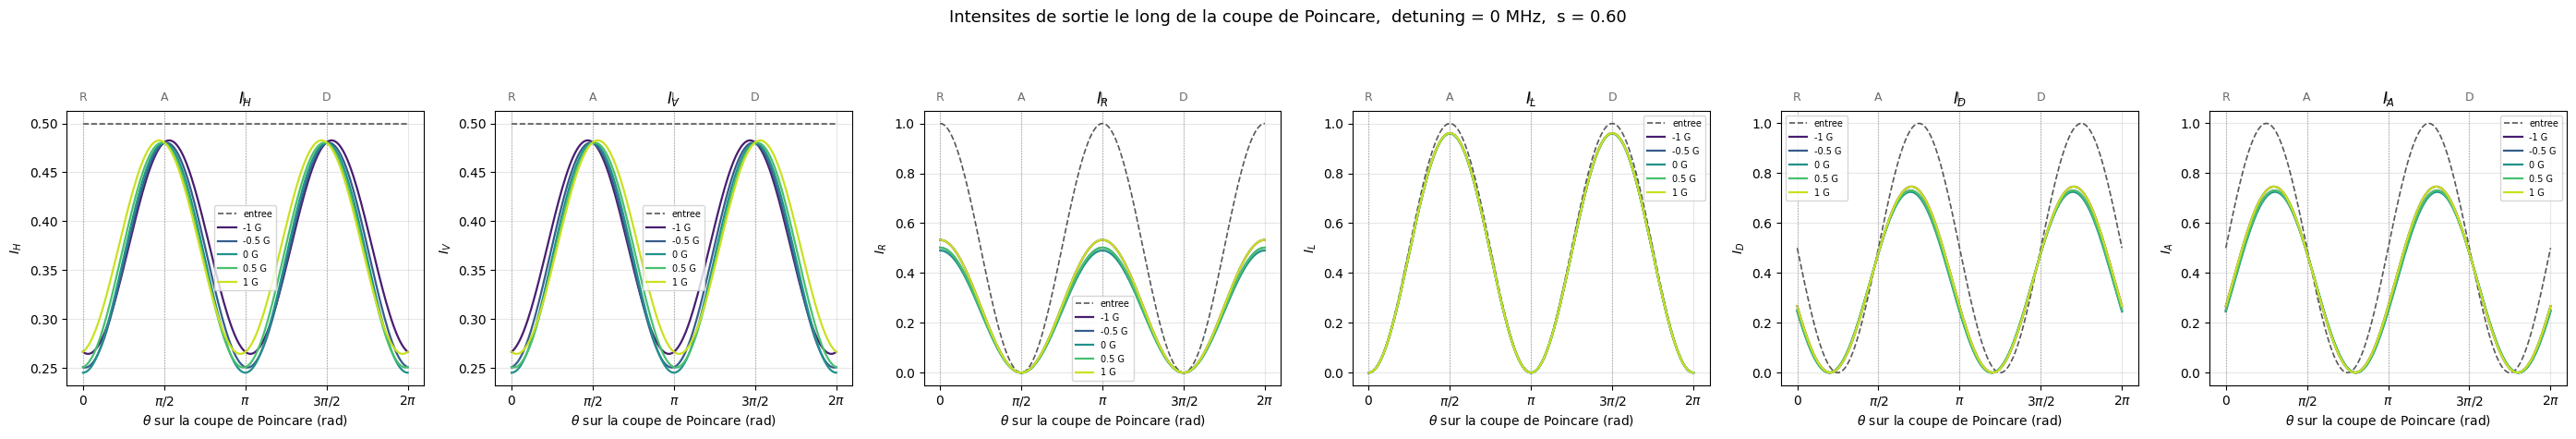

In [374]:
FIXED_DETUNING_FOR_B_HIGHLIGHT_MHz = 0.0
highlight_B_G = [-1.0, -0.5, 0.0, 0.5, 1.0]   # G, le long de B_vec

detuning_rad_fixed_highlight = np.array([2 * np.pi * FIXED_DETUNING_FOR_B_HIGHLIGHT_MHz * 1e6])
B_dir_highlight = np.array(B_vec, dtype=float) / np.linalg.norm(B_vec)

# Meme logique que pour le scan en detuning ci-dessus : un solve par valeur de
# B (le detuning etant ici fixe), reutilise pour tous les E_in de la coupe.
J_B_highlight = np.array([
    rb85_bloch.jones_matrix_closed(
        detuning_rad_fixed_highlight, Bn * 1e-4 * B_dir_highlight, pump_s, L_cell, n_rho,
        pump_detuning=pump_detuning, gamma_t=gamma_t,
    )[0]
    for Bn in highlight_B_G
])  # (n_B, 2, 2)

E_out_B_all = np.einsum('bij,tj->tbi', J_B_highlight, E_in_list)  # (theta, B, champ)

I_out_B_all = rb85_bloch.polarization_intensities(E_out_B_all)
I_in        = rb85_bloch.polarization_intensities(E_in_list)

output_intensities_B = {
    Bn: {k: v[:, j] for k, v in I_out_B_all.items()}
    for j, Bn in enumerate(highlight_B_G)
}

canon_x     = [0, np.pi / 2, np.pi, 3 * np.pi / 2]
canon_names = ["R", "A", "L", "D"]
highlight_colors_B = plt.cm.viridis(np.linspace(0.08, 0.92, len(highlight_B_G)))

fig, axs = plt.subplots(1, 6, figsize=(28, 4.8), sharex=True)
fig.suptitle(
    f"Intensites de sortie le long de la coupe de Poincare,  "
    f"detuning = {FIXED_DETUNING_FOR_B_HIGHLIGHT_MHz:g} MHz,  s = {pump_s:.2f}",
    fontsize=13,
)

for ax, key, label in [
    (axs[0], 'H', '$I_H$'), (axs[1], 'V', '$I_V$'),
    (axs[2], 'R', '$I_R$'), (axs[3], 'L', '$I_L$'),
    (axs[4], 'D', '$I_D$'), (axs[5], 'A', '$I_A$'),
]:
    ax.plot(theta_values, I_in[key], linestyle="--", color="black", linewidth=1.2, alpha=0.65, label="entree")
    for Bn, color in zip(highlight_B_G, highlight_colors_B):
        ax.plot(theta_values, output_intensities_B[Bn][key], color=color, linewidth=1.6, label=f"{Bn:g} G")
    for cx, cname in zip(canon_x, canon_names):
        ax.axvline(cx, color="gray", linewidth=0.8, linestyle=":", alpha=0.65)
        ax.text(cx, 1.03, cname, transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=9, color="dimgray")
    ax.set_title(label)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_xlabel(r"$\theta$ sur la coupe de Poincare (rad)")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

## Balayage complet en détuning : phase et amplitude de frange

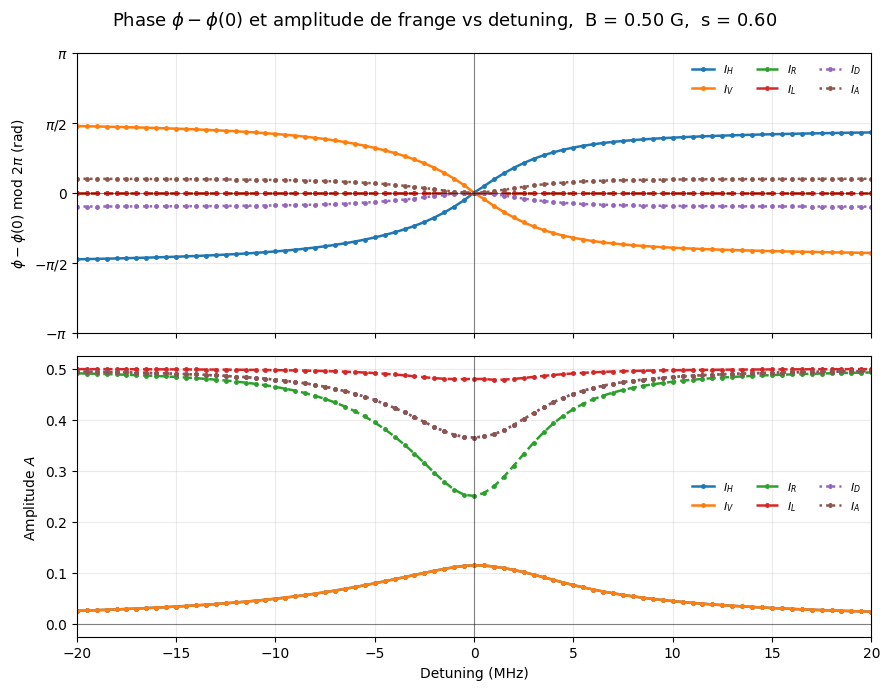

In [375]:
selected_detunings_MHz = np.linspace(-20, 20, 81)
detunings_rad_full     = 2 * np.pi * selected_detunings_MHz * 1e6

J_full = rb85_bloch.jones_matrix_closed(
    detunings_rad_full, B_T, pump_s, L_cell, n_rho,
    pump_detuning=pump_detuning, gamma_t=gamma_t,
)
E_out_full = np.einsum('dij,tj->tdi', J_full, E_in_list)
I_out_full = rb85_bloch.polarization_intensities(E_out_full)

# --- Fonctions de fit : I(theta) = c + A*sin(2*theta + phi) ---
_design = np.column_stack([np.ones_like(theta_values),
                            np.sin(2 * theta_values),
                            np.cos(2 * theta_values)])

def _fit_phase(y):
    """Retourne (phase, amplitude) du fit sin(2*theta+phi) sur y(theta)."""
    c, a, b = np.linalg.lstsq(_design, y, rcond=None)[0]
    A = np.sqrt(a**2 + b**2)
    if A < 1e-30:
        return np.nan, A
    y_norm = (y - c) / A
    design2 = np.column_stack([np.sin(2 * theta_values), np.cos(2 * theta_values)])
    sin_c, cos_c = np.linalg.lstsq(design2, y_norm, rcond=None)[0]
    return np.arctan2(cos_c, sin_c), A

def _zero_at_zero(detunings, phase_arr):
    p = np.unwrap(np.where(np.isfinite(phase_arr), phase_arr, np.nan))
    finite = np.isfinite(p)
    if not np.any(finite):
        return p
    return p - np.interp(0, detunings[finite], p[finite])

def _wrap_pi(phase):
    return (phase + np.pi) % (2 * np.pi) - np.pi

component_styles = [
    ('H', '$I_H$',  'tab:blue',   '-'),
    ('V', '$I_V$',  'tab:orange', '-'),
    ('R', '$I_R$',  'tab:green',  '--'),
    ('L', '$I_L$',  'tab:red',    '--'),
    ('D', '$I_D$',  'tab:purple', ':'),
    ('A', '$I_A$',  'tab:brown',  ':'),
]

phases_fit = {}
amps_fit   = {}
for key, *_ in component_styles:
    ph = np.array([_fit_phase(I_out_full[key][:, j])[0] for j in range(len(selected_detunings_MHz))])
    am = np.array([_fit_phase(I_out_full[key][:, j])[1] for j in range(len(selected_detunings_MHz))])
    phases_fit[key] = _zero_at_zero(selected_detunings_MHz, ph)
    amps_fit[key]   = am

AMP_THRESHOLD = 1e-2

fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
fig.suptitle(
    f"Phase $\\phi - \\phi(0)$ et amplitude de frange vs detuning,  B = {B_norm:.2f} G,  s = {pump_s:.2f}",
    fontsize=13,
)

for key, label, color, ls in component_styles:
    kw = dict(marker='o', markersize=2.5, linewidth=1.8, color=color, linestyle=ls, label=label)
    if np.nanmean(amps_fit[key]) > AMP_THRESHOLD:
        axs[0].plot(selected_detunings_MHz, _wrap_pi(phases_fit[key]), **kw)
    axs[1].plot(selected_detunings_MHz, amps_fit[key], **kw)

for ax in axs:
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.45)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.45)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=3, fontsize=8)

axs[0].set_ylabel(r'$\phi - \phi(0)$ mod $2\pi$ (rad)')
axs[0].set_ylim(-np.pi, np.pi)
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axs[0].set_yticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

axs[1].set_xlabel('Detuning (MHz)')
axs[1].set_ylabel(r'Amplitude $A$')
axs[1].set_xlim(selected_detunings_MHz.min(), selected_detunings_MHz.max())

plt.tight_layout()
plt.show()

## Déphasage vs B signé, à détuning fixe

Contrairement à `rb85_cell.py`, il n'y a ici aucun besoin de reconstruire un angle `theta = arccos(B.k_hat/|B|)` ni de figer un "axe de pompe" — `B_vec` entre **directement et linéairement** dans `zeeman_hamiltonian`. Le balayage en B signé est donc continu en B=0 par construction, sans le contournement que `test_sim.ipynb` doit faire pour `rb85_cell.py` (cf. ses cellules "Balayage en champ B").

**Point de calibration important** : cette cellule utilise directement `B_vec` défini plus haut (§1). Il doit impérativement **ne pas être aligné avec H ou V** (les axes d'analyse) : si B tombe exactement sur un axe, la matrice de Jones devient diagonale dans cette base et la phase H/V reste plate par construction mathématique, quelle que soit la physique — vérifié aussi bien sur ce module que sur `rb85_cell.py` non pompé. C'est pour ça que `B_vec=[1,1,0]` (45° de H/V) a été choisi au §1 plutôt que `[0,1,0]` — avec un vrai désalignement (comme dans n'importe quelle expérience réelle), le signal apparaît dès B~0.1 G.

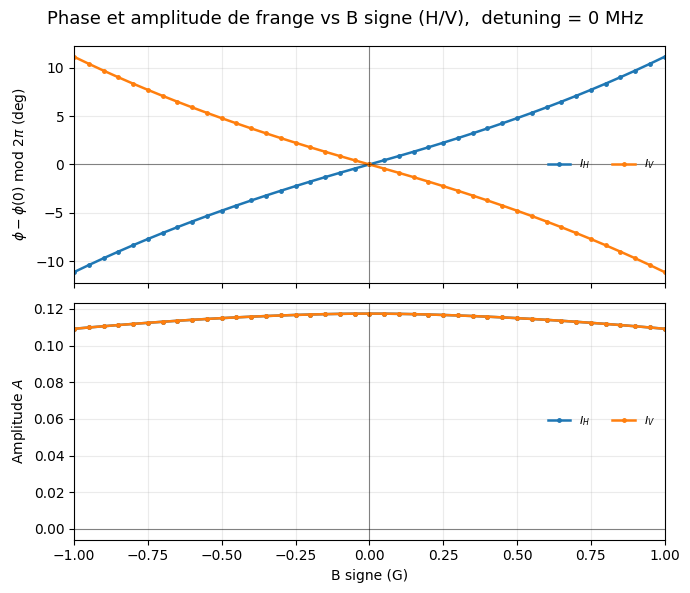

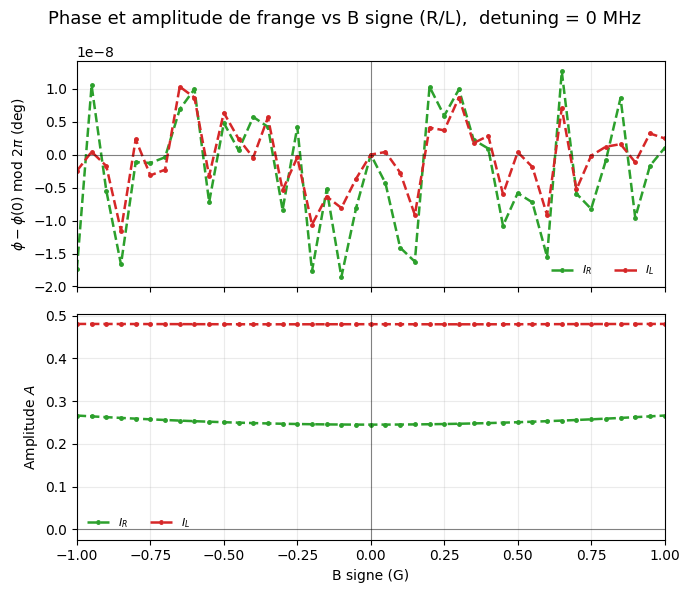

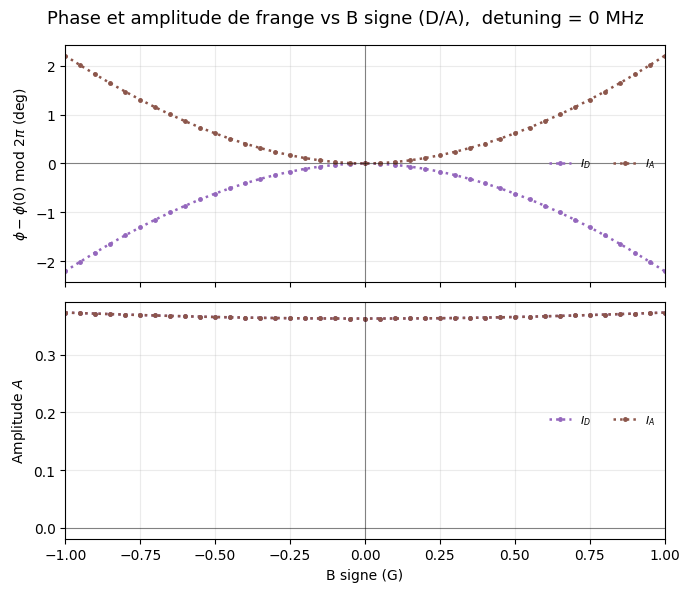

In [376]:
FIXED_DETUNING_MHZ = 0
B_scan_G           = np.linspace(-1, 1, 41)   # balayage de B signe (G) le long de B_vec

detuning_rad_fixed = 2 * np.pi * FIXED_DETUNING_MHZ * 1e6
B_dir = np.array(B_vec, dtype=float) / np.linalg.norm(B_vec)

J_Bscan = np.array([
    rb85_bloch.jones_matrix_closed(
        np.array([detuning_rad_fixed]), Bn * 1e-4 * B_dir, pump_s, L_cell, n_rho,
        pump_detuning=pump_detuning, gamma_t=gamma_t,
    )[0]
    for Bn in B_scan_G
])

E_out_Bscan = np.einsum('bij,tj->tbi', J_Bscan, E_in_list)
I_out_Bscan = rb85_bloch.polarization_intensities(E_out_Bscan)

phases_fit_B = {}
amps_fit_B   = {}
for key, *_ in component_styles:
    ph = np.array([_fit_phase(I_out_Bscan[key][:, j])[0] for j in range(len(B_scan_G))])
    am = np.array([_fit_phase(I_out_Bscan[key][:, j])[1] for j in range(len(B_scan_G))])
    phases_fit_B[key] = _zero_at_zero(B_scan_G, ph)
    amps_fit_B[key]   = am

# Un graphe independant par paire de composantes conjuguees (H/V, R/L, D/A),
# phase en degres avec echelle adaptive (pas de ylim fixe a +-180).
style_by_key = {key: (label, color, ls) for key, label, color, ls in component_styles}
axis_pairs = [('H', 'V'), ('R', 'L'), ('D', 'A')]

for k1, k2 in axis_pairs:
    fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
    fig.suptitle(
        f"Phase et amplitude de frange vs B signe ({k1}/{k2}),  detuning = {FIXED_DETUNING_MHZ:g} MHz",
        fontsize=13,
    )

    for key in (k1, k2):
        label, color, ls = style_by_key[key]
        kw = dict(marker='o', markersize=2.5, linewidth=1.8, color=color, linestyle=ls, label=label)
        if np.nanmean(amps_fit_B[key]) > AMP_THRESHOLD:
            axs[0].plot(B_scan_G, np.degrees(_wrap_pi(phases_fit_B[key])), **kw)
        axs[1].plot(B_scan_G, amps_fit_B[key], **kw)

    for ax in axs:
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.45)
        ax.axvline(0, color='black', linewidth=0.8, alpha=0.45)
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, ncol=2, fontsize=8)

    axs[0].set_ylabel(r'$\phi - \phi(0)$ mod $2\pi$ (deg)')

    axs[1].set_xlabel('B signe (G)')
    axs[1].set_ylabel(r'Amplitude $A$')
    axs[1].set_xlim(B_scan_G.min(), B_scan_G.max())

    plt.tight_layout()
    plt.show()

## Colormap : phase vs (détuning, B)

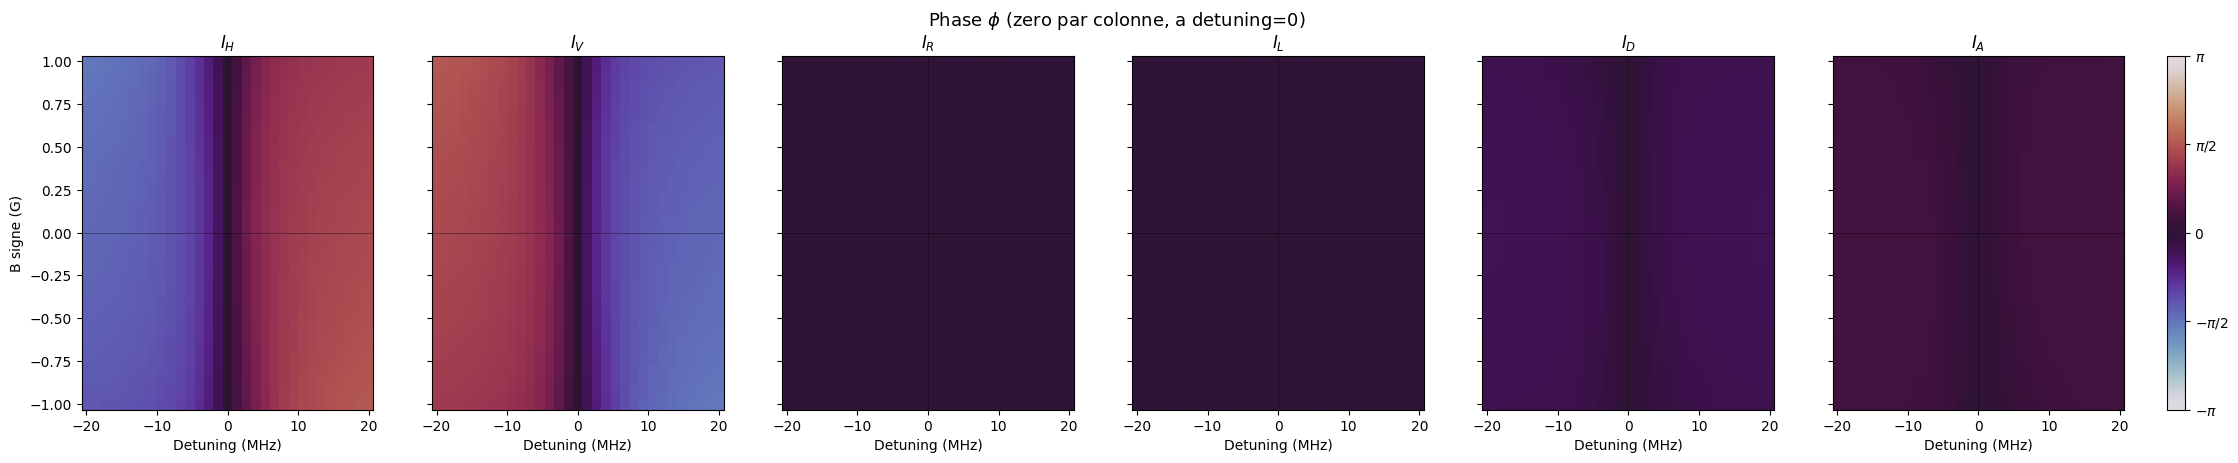

In [377]:
# Grille plus modeste que test_sim.ipynb (31x31 au lieu de 81x81) : chaque
# point est un vrai solve de Liouvillien, pas une formule fermee.
det_grid_MHz = np.linspace(-20, 20, 31)
B_grid_G     = np.linspace(-1.0, 1.0, 31)
det_grid_rad = 2 * np.pi * det_grid_MHz * 1e6

J_grid = np.array([
    rb85_bloch.jones_matrix_closed(
        det_grid_rad, Bn * 1e-4 * B_dir, pump_s, L_cell, n_rho,
        pump_detuning=pump_detuning, gamma_t=gamma_t,
    )
    for Bn in B_grid_G
])                                   # (n_B, n_det, 2, 2)
J_grid = np.transpose(J_grid, (1, 0, 2, 3))   # -> (n_det, n_B, 2, 2)

E_out_grid = np.einsum('dbij,tj->tdbi', J_grid, E_in_list)
I_out_grid = rb85_bloch.polarization_intensities(E_out_grid)   # chaque valeur : (181, n_det, n_B)

def _fit_phase_grid(Y):
    shape = Y.shape[1:]
    Yf = Y.reshape(len(theta_values), -1)
    c, a, b = np.linalg.lstsq(_design, Yf, rcond=None)[0]
    A = np.sqrt(a**2 + b**2)
    y_norm = np.divide(Yf - c, A, out=np.zeros_like(Yf), where=A > 1e-30)
    design2 = np.column_stack([np.sin(2 * theta_values), np.cos(2 * theta_values)])
    sin_c, cos_c = np.linalg.lstsq(design2, y_norm, rcond=None)[0]
    phase = np.where(A > 1e-30, np.arctan2(cos_c, sin_c), np.nan)
    return phase.reshape(shape), A.reshape(shape)

i0 = np.argmin(np.abs(det_grid_MHz))

phases_raw = {}
amps_grid  = {}
for key, *_ in component_styles:
    ph, am = _fit_phase_grid(I_out_grid[key])
    phases_raw[key] = ph
    amps_grid[key]  = am

sig_components = [(key, label) for key, label, *_ in component_styles
                   if np.nanmean(amps_grid[key]) > AMP_THRESHOLD]

phases_grid = {}
for key in phases_raw:
    p_unwrapped = np.unwrap(np.where(np.isfinite(phases_raw[key]), phases_raw[key], np.nan), axis=0)
    ref = p_unwrapped[i0, :]
    phases_grid[key] = p_unwrapped - ref[None, :]

fig, axs = plt.subplots(1, len(sig_components), figsize=(4.6 * len(sig_components), 4.6),
                         sharey=True, squeeze=False)
axs = axs[0]
fig.suptitle(r"Phase $\phi$ (zero par colonne, a detuning=0)", fontsize=13)

for ax, (key, label) in zip(axs, sig_components):
    im = ax.pcolormesh(det_grid_MHz, B_grid_G, phases_grid[key].T,
                        cmap='twilight', vmin=-np.pi, vmax=np.pi, shading='auto')
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.6, alpha=0.4)
    ax.set_title(label)
    ax.set_xlabel('Detuning (MHz)')

axs[0].set_ylabel('B signe (G)')
cbar = fig.colorbar(im, ax=list(axs), fraction=0.025, pad=0.02,
                     ticks=[-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar.ax.set_yticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

## Élargissement par puissance

C'est le point physique central de ce module : contrairement à `module.rb85_bloch.chi_tensor_from_rho` dans le code de référence (qui impose une largeur de raie fixe `Gamma_eff/2`), notre solve de réponse linéaire rigoureux fait sortir l'élargissement par puissance **automatiquement** de la structure spectrale du Liouvillien — sans qu'on l'impose nulle part.

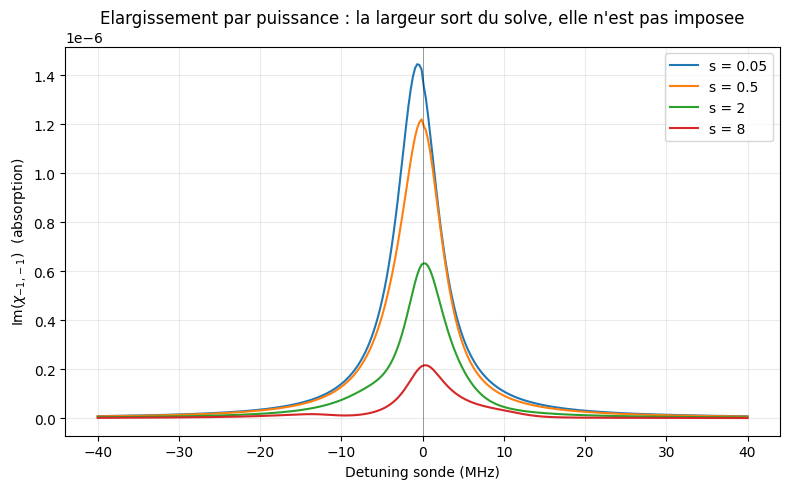

In [378]:
pump_s_values = [0.05, 0.5, 2.0, 8.0]
detunings_broad_MHz = np.linspace(-40, 40, 300)
detunings_broad_rad = 2 * np.pi * detunings_broad_MHz * 1e6

fig, ax = plt.subplots(figsize=(8, 5))
for s in pump_s_values:
    rho_s, L_s = rb85_bloch.steady_state_rho_closed(B_T, s, pump_detuning, gamma_t)
    chi_s = rb85_bloch.chi_tensor_from_rho(detunings_broad_rad, rho_s, L_s, n_rho)
    ax.plot(detunings_broad_MHz, chi_s[:, 0, 0].imag, label=f"s = {s:g}")

ax.axvline(0, color='black', linewidth=0.6, alpha=0.4)
ax.set_xlabel('Detuning sonde (MHz)')
ax.set_ylabel(r'Im($\chi_{-1,-1}$)  (absorption)')
ax.set_title("Elargissement par puissance : la largeur sort du solve, elle n'est pas imposee")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Comparaison : avec vs sans complément de Schur

Comme dans `rb85_cell.py` : `jones_matrix_closed` (avec Schur) vs `jones_matrix_approx` (bloc 2x2 nu). L'écart attendu est d'ordre χ² (Schur) contre χ (bloc nu).

ecart max sur E_out : 0.00e+00  (relatif : 0.00e+00)
ecart max sur la phase : 0.00e+00 rad


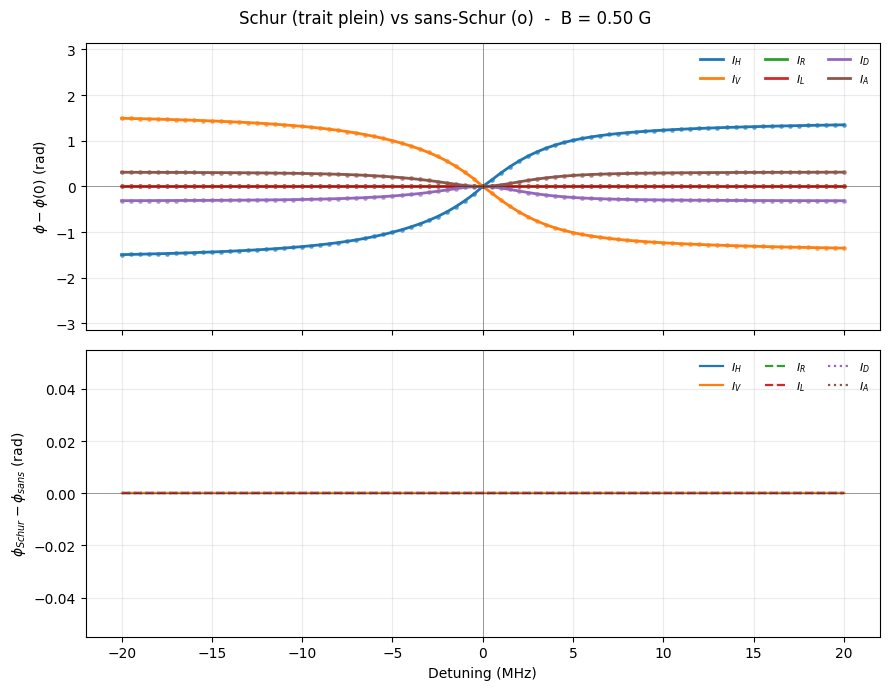

In [379]:
J_schur   = rb85_bloch.jones_matrix_closed(
    detunings_rad_full, B_T, pump_s, L_cell, n_rho,
    pump_detuning=pump_detuning, gamma_t=gamma_t, schur=True,
)
J_noschur = rb85_bloch.jones_matrix_approx(
    detunings_rad_full, B_T, pump_s, L_cell, n_rho,
    pump_detuning=pump_detuning, gamma_t=gamma_t,
)

E_out_schur   = np.einsum('dij,tj->tdi', J_schur, E_in_list)
E_out_noschur = np.einsum('dij,tj->tdi', J_noschur, E_in_list)

I_schur   = rb85_bloch.polarization_intensities(E_out_schur)
I_noschur = rb85_bloch.polarization_intensities(E_out_noschur)

champ_diff = np.max(np.abs(E_out_schur - E_out_noschur))
champ_rel  = champ_diff / np.max(np.abs(E_out_schur))
print(f"ecart max sur E_out : {champ_diff:.2e}  (relatif : {champ_rel:.2e})")

phases_schur, phases_noschur = {}, {}
for key, *_ in component_styles:
    ps = np.array([_fit_phase(I_schur[key][:, j])[0]   for j in range(len(selected_detunings_MHz))])
    pn = np.array([_fit_phase(I_noschur[key][:, j])[0] for j in range(len(selected_detunings_MHz))])
    phases_schur[key]   = _zero_at_zero(selected_detunings_MHz, ps)
    phases_noschur[key] = _zero_at_zero(selected_detunings_MHz, pn)

max_dphase = 0.0
for key, *_ in component_styles:
    if np.nanmean(amps_fit[key]) > AMP_THRESHOLD:
        d = np.nanmax(np.abs(_wrap_pi(phases_schur[key] - phases_noschur[key])))
        max_dphase = max(max_dphase, d)
print(f"ecart max sur la phase : {max_dphase:.2e} rad")

fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
fig.suptitle(f"Schur (trait plein) vs sans-Schur (o)  -  B = {B_norm:.2f} G", fontsize=12)

for key, label, color, ls in component_styles:
    if np.nanmean(amps_fit[key]) <= AMP_THRESHOLD:
        continue
    axs[0].plot(selected_detunings_MHz, _wrap_pi(phases_schur[key]),
                color=color, ls='-', lw=2.0, label=label)
    axs[0].plot(selected_detunings_MHz, _wrap_pi(phases_noschur[key]),
                color=color, ls='', marker='o', ms=2.5, alpha=0.55)
    axs[1].plot(selected_detunings_MHz, _wrap_pi(phases_schur[key] - phases_noschur[key]),
                color=color, ls=ls, lw=1.6, label=label)

axs[0].set_ylabel(r'$\phi - \phi(0)$ (rad)')
axs[0].set_ylim(-np.pi, np.pi)
axs[0].legend(frameon=False, ncol=3, fontsize=8)
axs[1].set_ylabel(r'$\phi_{Schur} - \phi_{sans}$ (rad)')
axs[1].set_xlabel('Detuning (MHz)')
axs[1].legend(frameon=False, ncol=3, fontsize=8)
for ax in axs:
    ax.axhline(0, color='black', lw=0.6, alpha=0.4)
    ax.axvline(0, color='black', lw=0.6, alpha=0.4)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Vérification de physicité sur toute la grille

Aucune inversion de population n'est possible par pompage optique seul sur cette transition fermée : `Im(chi)` doit rester positif (absorptif) partout, sur toute la grille (détuning, B) déjà balayée ci-dessus.

In [380]:
min_im_chi = np.inf
for Bn in B_grid_G:
    rho_b, L_b = rb85_bloch.steady_state_rho_closed(Bn * 1e-4 * B_dir, pump_s, pump_detuning, gamma_t)
    chi_b = rb85_bloch.chi_tensor_from_rho(det_grid_rad, rho_b, L_b, n_rho)
    min_im_chi = min(min_im_chi, chi_b[:, 0, 0].imag.min(), chi_b[:, 1, 1].imag.min(), chi_b[:, 2, 2].imag.min())

print(f"Im(chi) minimum sur toute la grille (detuning, B) : {min_im_chi:.3e}")
print("=> jamais negatif : pas de gain, coherent avec un milieu jamais inverse par pompage optique seul.")

Im(chi) minimum sur toute la grille (detuning, B) : 2.466e-09
=> jamais negatif : pas de gain, coherent avec un milieu jamais inverse par pompage optique seul.
